In [2]:
# ============================================================
# FUNCTION 4 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load the original Function 4 data
# ------------------------------------------------------------

X = np.load("function4/initial_inputs.npy")
Y = np.load("function4/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([
    [0.370368, 0.421656, 0.371701, 0.447899]
])
week1_y = np.array([
    0.17319018408919762
])

week2_x = np.array([
    [0.413742, 0.470182, 0.290309, 0.439853]
])
week2_y = np.array([
    -1.7902558622959037
])

week3_x = np.array([
    [0.379028, 0.410913, 0.447054, 0.442255]
])
week3_y = np.array([
    -0.06479142792096892
])

week4_x = np.array([
    [0.339565, 0.421924, 0.397318, 0.438082]
])
week4_y = np.array([
    0.2806521851858581
])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)

# ------------------------------------------------------------
# 3. Fit an ARD Gaussian Process
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([0.25, 0.25, 0.20, 0.25]),
        length_scale_bounds=(0.01, 3.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=54
)

gp.fit(X, Y)

print("\nFitted kernel:")
print(gp.kernel_)

# ------------------------------------------------------------
# 4. Inspect fitted input sensitivity
# ------------------------------------------------------------

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:", lengthscales)
print("Normalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

# ------------------------------------------------------------
# 5. Generate candidates
#
# Week 4 improved strongly, so most candidates are local.
# Smaller movements are used around the current best because
# nearby observations have previously produced very different
# outputs.
# ------------------------------------------------------------

rng = np.random.default_rng(54)

very_local = rng.normal(
    loc=best_x,
    scale=[0.008, 0.008, 0.008, 0.008],
    size=(20_000, 4)
)

local = rng.normal(
    loc=best_x,
    scale=[0.025, 0.025, 0.020, 0.025],
    size=(20_000, 4)
)

wider_local = rng.normal(
    loc=best_x,
    scale=[0.060, 0.060, 0.050, 0.060],
    size=(10_000, 4)
)

# Explore the region between the two strongest observed points
blend_weights = rng.uniform(
    0,
    1,
    size=(10_000, 1)
)

blended_candidates = (
    blend_weights * week1_x
    + (1 - blend_weights) * week4_x
)

blended_candidates += rng.normal(
    loc=0,
    scale=[0.012, 0.012, 0.012, 0.012],
    size=(10_000, 4)
)

# Retain a small global pool
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, 4)
)

candidates = np.vstack([
    very_local,
    local,
    wider_local,
    blended_candidates,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 6. Remove candidates too close to previous observations
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

candidates = candidates[
    minimum_distance > 0.003
]

# ------------------------------------------------------------
# 7. Predict candidate performance
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)

# Expected Improvement
xi = 0.002

improvement = mean - best_y - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std

    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

# Moderate UCB
kappa = 0.55
ucb = mean + kappa * std

# ------------------------------------------------------------
# 8. Filter out weak predicted points
# ------------------------------------------------------------

mean_filter = mean >= (best_y - 0.08)

if np.sum(mean_filter) < 100:
    mean_filter = mean >= np.percentile(mean, 90)

filtered_candidates = candidates[mean_filter]
filtered_mean = mean[mean_filter]
filtered_std = std[mean_filter]
filtered_ei = expected_improvement[mean_filter]
filtered_ucb = ucb[mean_filter]

# Normalise acquisition values
ei_normalised = (
    filtered_ei - filtered_ei.min()
) / (
    filtered_ei.max()
    - filtered_ei.min()
    + 1e-12
)

ucb_normalised = (
    filtered_ucb - filtered_ucb.min()
) / (
    filtered_ucb.max()
    - filtered_ucb.min()
    + 1e-12
)

# Mostly exploit the successful Week 4 region
acquisition = (
    0.80 * ei_normalised
    + 0.20 * ucb_normalised
)

best_candidate_index = np.argmax(acquisition)
week5_query = filtered_candidates[best_candidate_index]

# ------------------------------------------------------------
# 9. Print the proposed query
# ------------------------------------------------------------

print("\nMethod:")
print("Local filtered Expected Improvement with small UCB component")

print("\nCandidates passing mean filter:",
      len(filtered_candidates))

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(
    f"{value:.6f}"
    for value in week5_query
))

print("\nPredicted mean:",
      filtered_mean[best_candidate_index])

print("Predicted standard deviation:",
      filtered_std[best_candidate_index])

print("Expected Improvement:",
      filtered_ei[best_candidate_index])

print("UCB:",
      filtered_ucb[best_candidate_index])

print("Distance from Week 4 point:",
      np.linalg.norm(
          week5_query - week4_x[0]
      ))

print("Distance from Week 1 point:",
      np.linalg.norm(
          week5_query - week1_x[0]
      ))

X shape: (34, 4)
Y shape: (34,)

Best observed input: [0.339565 0.421924 0.397318 0.438082]
Best observed output: 0.2806521851858581

Fitted kernel:
2.72**2 * Matern(length_scale=[1.65, 1.35, 1.35, 1.43], nu=2.5) + WhiteKernel(noise_level=0.000708)

Fitted lengthscales: [1.65377021 1.35379581 1.35348043 1.43099711]
Normalised input influence:
x1: 0.2174
x2: 0.2656
x3: 0.2657
x4: 0.2513

Method:
Local filtered Expected Improvement with small UCB component

Candidates passing mean filter: 6495

Suggested Week 5 query:
[0.35781197 0.42090365 0.42424424 0.43076232]

Portal format:
0.357812-0.420904-0.424244-0.430762

Predicted mean: 0.17718657450723363
Predicted standard deviation: 0.27570511065730646
Expected Improvement: 0.06520833235324633
UCB: 0.3288243853687522
Distance from Week 4 point: 0.033355557734057746
Distance from Week 1 point: 0.05668049428914777


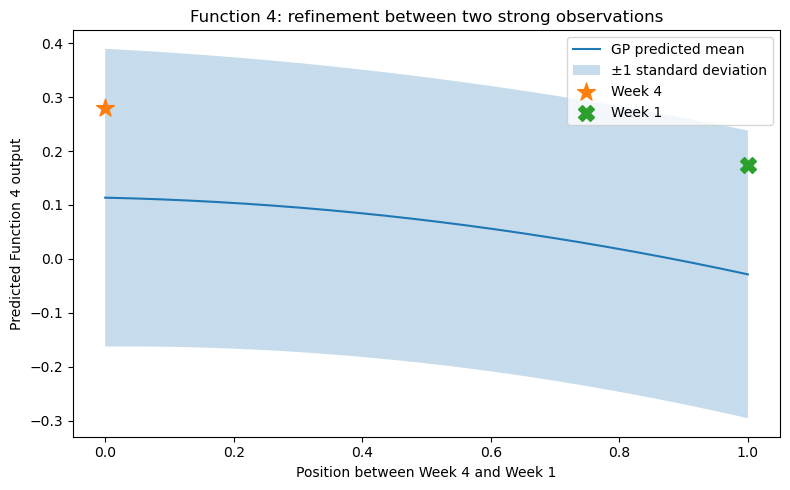

In [3]:
# ------------------------------------------------------------
# 10. Plot the path between Week 1 and Week 4
# ------------------------------------------------------------

import matplotlib.pyplot as plt

path_weights = np.linspace(0, 1, 300)

path_points = (
    path_weights[:, None] * week1_x
    + (1 - path_weights[:, None]) * week4_x
)

path_mean, path_std = gp.predict(
    path_points,
    return_std=True
)

plt.figure(figsize=(8, 5))

plt.plot(
    path_weights,
    path_mean,
    label="GP predicted mean"
)

plt.fill_between(
    path_weights,
    path_mean - path_std,
    path_mean + path_std,
    alpha=0.25,
    label="±1 standard deviation"
)

plt.scatter(
    0,
    week4_y[0],
    marker="*",
    s=180,
    label="Week 4"
)

plt.scatter(
    1,
    week1_y[0],
    marker="X",
    s=130,
    label="Week 1"
)

plt.xlabel("Position between Week 4 and Week 1")
plt.ylabel("Predicted Function 4 output")
plt.title("Function 4: refinement between two strong observations")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Small neural-network comparison for Function 4

import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(54)
np.random.seed(54)

# X and Y should already contain the original data plus Weeks 1–4 once
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
Y_scaled = y_scaler.fit_transform(Y.reshape(-1, 1))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(8, activation="tanh"),
    tf.keras.layers.Dense(4, activation="tanh"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

history = model.fit(
    X_scaled,
    Y_scaled,
    epochs=300,
    verbose=0
)

print("Final training loss:", history.history["loss"][-1])

E0000 00:00:1785358766.181090    1241 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Final training loss: 0.0017847479321062565


In [5]:
week4_point = np.array([
    [0.339565, 0.421924, 0.397318, 0.438082]
])

week4_scaled = x_scaler.transform(week4_point)
week4_tensor = tf.convert_to_tensor(
    week4_scaled,
    dtype=tf.float32
)

with tf.GradientTape() as tape:
    tape.watch(week4_tensor)
    prediction = model(week4_tensor)

gradients_scaled = tape.gradient(
    prediction,
    week4_tensor
).numpy()[0]

# Convert approximately back to the original input scale
gradients_original = (
    gradients_scaled
    * y_scaler.scale_[0]
    / x_scaler.scale_
)

print("Neural-network prediction:",
      y_scaler.inverse_transform(
          prediction.numpy()
      )[0, 0])

print("\nInput gradients at Week 4 point:")

for i, gradient in enumerate(
    gradients_original,
    start=1
):
    print(f"x{i}: {gradient:.6f}")

print("\nAbsolute gradient importance:")

absolute_gradients = np.abs(gradients_original)
relative_importance = (
    absolute_gradients
    / absolute_gradients.sum()
)

for i, importance in enumerate(
    relative_importance,
    start=1
):
    print(f"x{i}: {importance:.3f}")

Neural-network prediction: -0.039164737

Input gradients at Week 4 point:
x1: 10.917896
x2: 8.012002
x3: -17.484805
x4: 12.807469

Absolute gradient importance:
x1: 0.222
x2: 0.163
x3: 0.355
x4: 0.260
